### Importation des bibliothèques

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [138]:
data=pd.read_csv("../data/data_preprocessed.csv")

In [139]:
data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,no_assessment_taken,low_performance,grade2_echec,Marital_status_grouped,Application_mode_grouped,Mother's_qualification_grouped,Father's_qualification_grouped,Mother's_occupation_grouped,Father's_occupation_grouped,Previous_qualification_grouped
0,1,17,5,Animation et conception multimédia,journée,1,122.0,1,19,12,...,0,0,0,Single,2e phase - contingent général,Éducation de base,Enseignement secondaire,Services / vente / sécurité,Travailleurs non qualifiés,Enseignement secondaire
1,1,15,1,Tourisme,journée,1,160.0,1,1,3,...,0,0,0,Single,Other,Enseignement secondaire,Enseignement supérieur,Techniciens / professions intermédiaires,Techniciens / professions intermédiaires,Enseignement secondaire
2,1,1,5,Design de communication,journée,1,122.0,1,37,37,...,1,0,0,Single,1ère phase - contingent général,Éducation de base,Éducation de base,Travailleurs non qualifiés,Travailleurs non qualifiés,Enseignement secondaire
3,1,17,2,Journalisme et communication,journée,1,122.0,1,38,37,...,0,0,0,Single,2e phase - contingent général,Éducation de base,Éducation de base,Services / vente / sécurité,Techniciens / professions intermédiaires,Enseignement secondaire
4,2,39,1,Service social (présence en soirée),soirée,1,100.0,1,37,38,...,0,0,0,Married,Plus de 23 ans,Éducation de base,Éducation de base,Travailleurs non qualifiés,Travailleurs non qualifiés,Enseignement secondaire


In [140]:
data1=data.drop(columns=["Marital status","Application mode","Previous qualification","Nacionality","Mother's qualification","Father's qualification",
"Mother's occupation","Father's occupation"])

In [141]:
data1.columns

Index(['Application order', 'Course', 'Daytime/evening attendance',
       'Previous qualification (grade)', 'Admission grade', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)', 'Unemployment rate',
       'Inflation rate', 'GDP', 'Target', 'no_academic_activity',
       'no_assessment_taken', 'low_performance',

In [142]:
infos=data1.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 40 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Application order                               4424 non-null   int64  
 1   Course                                          4424 non-null   str    
 2   Daytime/evening attendance                      4424 non-null   str    
 3   Previous qualification (grade)                  4424 non-null   float64
 4   Admission grade                                 4424 non-null   float64
 5   Displaced                                       4424 non-null   str    
 6   Educational special needs                       4424 non-null   str    
 7   Debtor                                          4424 non-null   str    
 8   Tuition fees up to date                         4424 non-null   str    
 9   Gender                                          4424

In [143]:
X=data1.drop(columns="Target")
Y=data1["Target"]

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns


print(num_cols)
print(cat_cols)

Index(['Application order', 'Previous qualification (grade)',
       'Admission grade', 'Age at enrollment',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)', 'Unemployment rate',
       'Inflation rate', 'GDP', 'no_academic_activity', 'no_assessment_taken',
       'low_performance', 'grade2_echec'],
      dtype='str')
Index(['Course', 'Daytime/evening attendance', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scho

C:\Users\Dell\AppData\Local\Temp\ipykernel_23844\1519243517.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'category']).columns


In [144]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=72)

In [145]:
def model_train(modele,numerical,categorical,x_train,y_train):
    preprocessor1=ColumnTransformer([
        ("num",StandardScaler(),numerical),
        ("cat",OneHotEncoder(),categorical)
    ])

    pipeline=Pipeline(steps=[
        ("preprocessor",preprocessor1),
        ("classifier",modele)])
    pipeline.fit(x_train,y_train)
    print(x_train[categorical[12]].unique())
    print(x_test[categorical[12]].unique())
    return pipeline
    

def resultats(x_train,y_train,x_test,y_test,pipeline):
    print(f"accuracy_train={accuracy_score(y_train,pipeline.predict(x_train))}")
    print(f"accuracy_test={accuracy_score(y_test,pipeline.predict(x_test))}")

    y_pred=pipeline.predict(x_test)
    print(classification_report(y_test,y_pred))
    confusion=confusion_matrix(y_test,y_pred)

    sns.heatmap(confusion,annot=True,fmt="d")


def validation():
    pass

In [146]:
model1=model_train(LogisticRegression(max_iter=1000),num_cols,cat_cols,x_train,y_train)

<ArrowStringArray>
[                    'Éducation de base',
                'Enseignement supérieur',
                               'Inconnu',
               'Enseignement secondaire',
 'Formation professionnelle / technique',
           'Faible niveau d'instruction']
Length: 6, dtype: str
<ArrowStringArray>
[                    'Éducation de base',
               'Enseignement secondaire',
                'Enseignement supérieur',
                               'Inconnu',
 'Formation professionnelle / technique',
           'Faible niveau d'instruction']
Length: 6, dtype: str


accuracy_train=0.7951398700197796
accuracy_test=0.7875706214689265
              precision    recall  f1-score   support

           1       0.80      0.81      0.80       284
           2       0.82      0.92      0.87       442
           3       0.60      0.40      0.48       159

    accuracy                           0.79       885
   macro avg       0.74      0.71      0.72       885
weighted avg       0.77      0.79      0.78       885



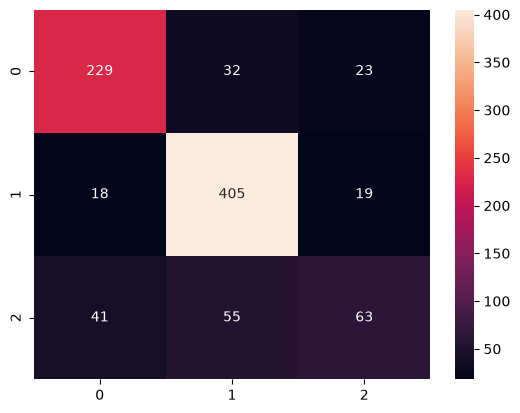

In [147]:
resultats(x_train,y_train,x_test,y_test,model1)

In [148]:
model2=model_train(LogisticRegression(max_iter=1000,class_weight="balanced"),num_cols,cat_cols,x_train,y_train)

<ArrowStringArray>
[                    'Éducation de base',
                'Enseignement supérieur',
                               'Inconnu',
               'Enseignement secondaire',
 'Formation professionnelle / technique',
           'Faible niveau d'instruction']
Length: 6, dtype: str
<ArrowStringArray>
[                    'Éducation de base',
               'Enseignement secondaire',
                'Enseignement supérieur',
                               'Inconnu',
 'Formation professionnelle / technique',
           'Faible niveau d'instruction']
Length: 6, dtype: str


accuracy_train=0.7702740887256287
accuracy_test=0.7457627118644068
              precision    recall  f1-score   support

           1       0.81      0.76      0.78       284
           2       0.87      0.79      0.83       442
           3       0.44      0.60      0.51       159

    accuracy                           0.75       885
   macro avg       0.71      0.72      0.71       885
weighted avg       0.77      0.75      0.76       885



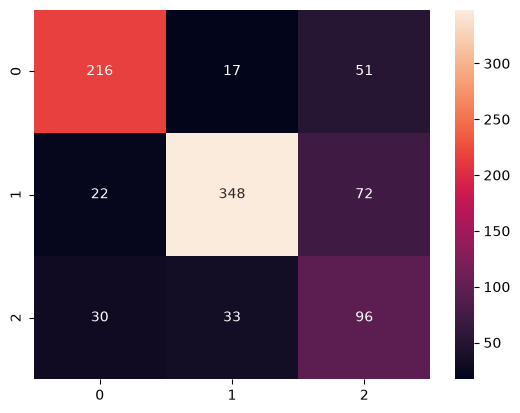

In [149]:
resultats(x_train,y_train,x_test,y_test,model2)

In [150]:
data2=data1.drop(columns=['no_academic_activity','no_assessment_taken','low_performance','grade2_echec'])

In [151]:
X=data2.drop(columns="Target")
Y=data2["Target"]

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns


print(num_cols)
print(cat_cols)

Index(['Application order', 'Previous qualification (grade)',
       'Admission grade', 'Age at enrollment',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)', 'Unemployment rate',
       'Inflation rate', 'GDP'],
      dtype='str')
Index(['Course', 'Daytime/evening attendance', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'International',
       'Marital_status_grouped', 'Application_mode_grou

C:\Users\Dell\AppData\Local\Temp\ipykernel_23844\2714691840.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'category']).columns


In [152]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=72)

In [153]:
model3=model_train(LogisticRegression(max_iter=1000),num_cols,cat_cols,x_train,y_train)

<ArrowStringArray>
[                    'Éducation de base',
                'Enseignement supérieur',
                               'Inconnu',
               'Enseignement secondaire',
 'Formation professionnelle / technique',
           'Faible niveau d'instruction']
Length: 6, dtype: str
<ArrowStringArray>
[                    'Éducation de base',
               'Enseignement secondaire',
                'Enseignement supérieur',
                               'Inconnu',
 'Formation professionnelle / technique',
           'Faible niveau d'instruction']
Length: 6, dtype: str


accuracy_train=0.7900536874823396
accuracy_test=0.7875706214689265
              precision    recall  f1-score   support

           1       0.80      0.82      0.81       284
           2       0.82      0.92      0.86       442
           3       0.61      0.36      0.46       159

    accuracy                           0.79       885
   macro avg       0.74      0.70      0.71       885
weighted avg       0.77      0.79      0.77       885



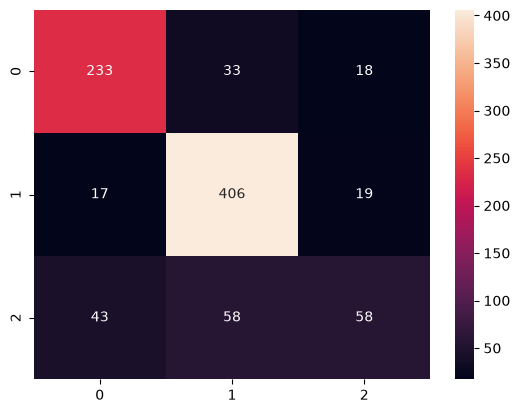

In [154]:
resultats(x_train,y_train,x_test,y_test,model3)

In [155]:
model4=model_train(LogisticRegression(max_iter=1000,class_weight="balanced"),num_cols,cat_cols,x_train,y_train)

<ArrowStringArray>
[                    'Éducation de base',
                'Enseignement supérieur',
                               'Inconnu',
               'Enseignement secondaire',
 'Formation professionnelle / technique',
           'Faible niveau d'instruction']
Length: 6, dtype: str
<ArrowStringArray>
[                    'Éducation de base',
               'Enseignement secondaire',
                'Enseignement supérieur',
                               'Inconnu',
 'Formation professionnelle / technique',
           'Faible niveau d'instruction']
Length: 6, dtype: str


accuracy_train=0.7722520486012998
accuracy_test=0.7502824858757062
              precision    recall  f1-score   support

           1       0.80      0.77      0.78       284
           2       0.87      0.80      0.83       442
           3       0.45      0.59      0.51       159

    accuracy                           0.75       885
   macro avg       0.71      0.72      0.71       885
weighted avg       0.77      0.75      0.76       885



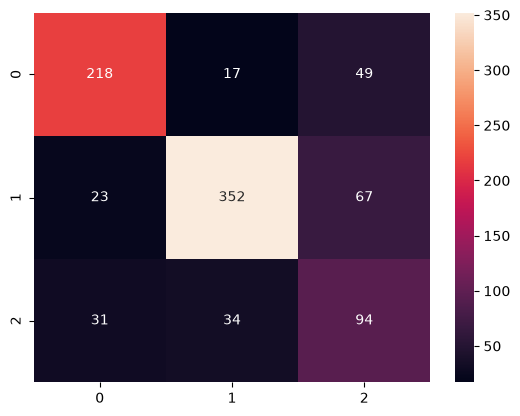

In [156]:
resultats(x_train,y_train,x_test,y_test,model4)